# Feature Engineering and Analysis for OKS Outcome Classification

**Objective**: Build features for a classification model that predicts poor outcomes based on OKS score changes.

**Target Variable Definition**:
- **Good Outcome (1)**: OKS improvement (t1 - t0) >= 7 points
- **Poor Outcome (0)**: OKS improvement (t1 - t0) < 7 points

**Key Principles**:
- No data leakage: Only use information available before/at surgery time (t0)
- Avoid using post-surgery outcomes (t1 scores, complications after surgery)
- Focus on baseline characteristics, pre-surgery health, and surgical factors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Data Loading and Initial Exploration

In [2]:
# Load the cleaned data
data_path = '../data/cleaned/knee-provider-cleaned.parquet'
df = pd.read_parquet(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (132382, 81)

Number of rows: 132,382
Number of columns: 81


In [3]:
# Display first few rows
df.head()

,provider_code,procedure,revision_flag,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,...,oks_t1_walking,oks_t1_standing,oks_t1_limping,oks_t1_kneeling,oks_t1_work,oks_t1_confidence,oks_t1_shopping,oks_t1_stairs,oks_t1_score,oks_oks_t1_predicted
0,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,3,3,4,2,4,4,4,3,40.0,34.825798
1,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,4,4,4,3,3,3,4,4,44.0,43.180367
2,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,4,4,4,2,4,4,4,4,46.0,42.201862
3,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,1,4,4,1,3,3,4,3,36.0,36.826900
4,ADP02,Knee Replacement,0,2018/19,NaN,NaN,1,0,3,2,...,2,3,3,2,2,3,2,1,28.0,33.434299


In [4]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132382 entries, 0 to 139235
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   provider_code                 132382 non-null  category
 1   procedure                     132382 non-null  category
 2   revision_flag                 132382 non-null  uint8   
 3   year                          132382 non-null  category
 4   age_band                      123354 non-null  category
 5   gender                        123354 non-null  float32 
 6   t0_assisted                   132382 non-null  uint8   
 7   t0_assisted_by                132382 non-null  uint8   
 8   t0_symptom_period             132382 non-null  uint8   
 9   t0_previous_surgery           132382 non-null  uint8   
 10  t0_living_arrangements        132382 non-null  uint8   
 11  t0_disability                 132382 non-null  uint8   
 12  heart_disease                 13238

In [5]:
# Statistical summary
df.describe()

,revision_flag,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,heart_disease,high_bp,...,oks_t1_walking,oks_t1_standing,oks_t1_limping,oks_t1_kneeling,oks_t1_work,oks_t1_confidence,oks_t1_shopping,oks_t1_stairs,oks_t1_score,oks_oks_t1_predicted
count,132382.0,123354.000000,132382.000000,132382.0,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,...,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,129983.000000,128931.000000
mean,0.0,1.572304,1.921039,0.0,2.649756,2.005295,1.345999,1.815496,8.256757,5.461875,...,3.411801,3.141938,3.147868,1.676436,3.113973,3.548383,3.233060,3.085125,36.143318,34.673317
std,0.0,0.494747,0.815967,0.0,1.031559,0.617852,1.027073,1.581115,2.322407,3.973259,...,1.115834,1.011155,1.190938,1.479360,1.097922,0.928941,1.269813,1.128362,9.301224,4.464723
min,0.0,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.453117
25%,0.0,1.000000,2.000000,0.0,2.000000,2.000000,1.000000,1.000000,9.000000,1.000000,...,3.000000,3.000000,3.000000,0.000000,2.000000,3.000000,3.000000,2.000000,31.000000,31.839390
50%,0.0,2.000000,2.000000,0.0,2.000000,2.000000,1.000000,2.000000,9.000000,9.000000,...,4.000000,3.000000,3.000000,2.000000,3.000000,4.000000,4.000000,3.000000,38.000000,35.221458
75%,0.0,2.000000,2.000000,0.0,3.000000,2.000000,1.000000,2.000000,9.000000,9.000000,...,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,44.000000,38.079254
max,0.0,2.000000,9.000000,0.0,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,48.000000,44.520660


## 2. Create Target Variable (No Data Leakage)

**CRITICAL**: The target variable calculation uses t1 scores, but this is ONLY for creating the label.
We will NOT use oks_t1_score or any post-surgery outcomes as features in the model.

In [6]:
# Check if OKS scores exist
print("Available columns:")
print([col for col in df.columns if 'oks' in col.lower()])

Available columns:
['oks_eq_5d_index_t1_predicted', 'oks_eq_vas_t1_predicted', 'oks_t0_pain', 'oks_t0_night_pain', 'oks_t0_washing', 'oks_t0_transport', 'oks_t0_walking', 'oks_t0_standing', 'oks_t0_limping', 'oks_t0_kneeling', 'oks_t0_work', 'oks_t0_confidence', 'oks_t0_shopping', 'oks_t0_stairs', 'oks_t0_score', 'oks_t1_pain', 'oks_t1_night_pain', 'oks_t1_washing', 'oks_t1_transport', 'oks_t1_walking', 'oks_t1_standing', 'oks_t1_limping', 'oks_t1_kneeling', 'oks_t1_work', 'oks_t1_confidence', 'oks_t1_shopping', 'oks_t1_stairs', 'oks_t1_score', 'oks_oks_t1_predicted']


In [7]:
# Create target variable
# Good outcome (1): improvement >= 7 points
# Poor outcome (0): improvement < 7 points

df['oks_improvement'] = df['oks_t1_score'] - df['oks_t0_score']
df['target'] = (df['oks_improvement'] <= 7).astype(int)

print("Target Variable Distribution:")
print(df['target'].value_counts())
print("\nPercentage Distribution:")
print(df['target'].value_counts(normalize=True) * 100)

Target Variable Distribution:
target
0    110909
1     21473
Name: count, dtype: int64

Percentage Distribution:
target
0    83.779517
1    16.220483
Name: proportion, dtype: float64


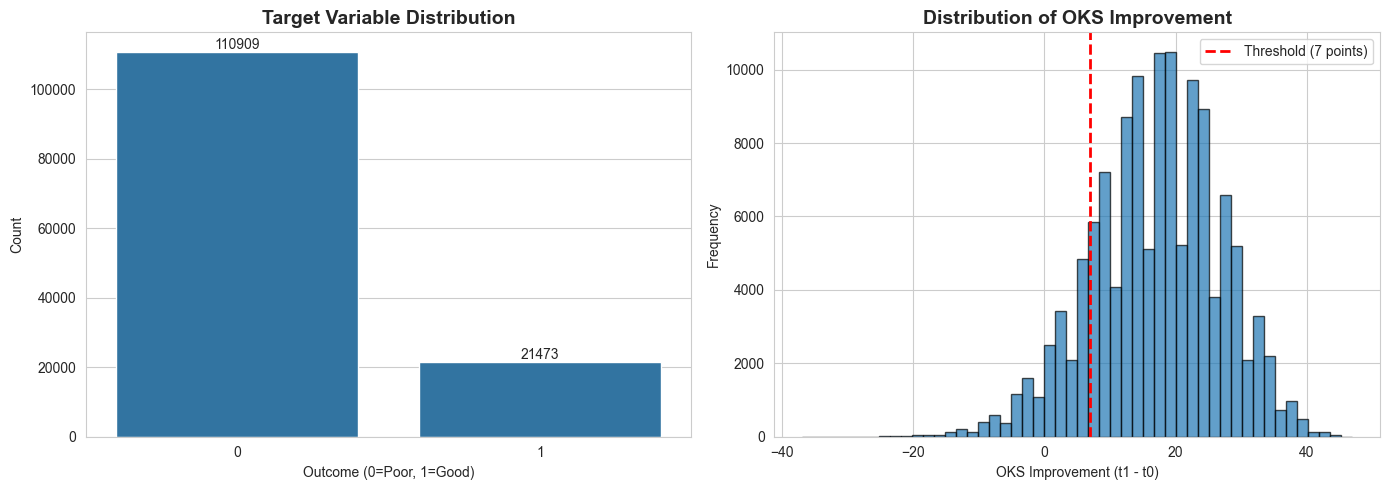


OKS Improvement Statistics:
count    129983.000000
mean         17.040813
std           9.793470
min         -37.000000
25%          11.000000
50%          18.000000
75%          24.000000
max          47.000000
Name: oks_improvement, dtype: float64


In [8]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='target', ax=axes[0])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome (0=Poor, 1=Good)')
axes[0].set_ylabel('Count')

# Add percentages on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Distribution of OKS improvement
axes[1].hist(df['oks_improvement'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=7, color='red', linestyle='--', linewidth=2, label='Threshold (7 points)')
axes[1].set_title('Distribution of OKS Improvement', fontsize=14, fontweight='bold')
axes[1].set_xlabel('OKS Improvement (t1 - t0)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nOKS Improvement Statistics:")
print(df['oks_improvement'].describe())

## 3. Identify Feature Categories and Data Leakage Risks

In [9]:
# Categorize features by leakage risk

# SAFE FEATURES (can be used) - available before/at surgery
safe_demographic = [col for col in df.columns if any(x in col.lower() for x in ['age', 'gender', 'sex'])]
safe_baseline_health = [col for col in df.columns if 't0' in col.lower() and 'oks' not in col.lower()]
safe_baseline_oks = ['oks_t0_score']  # Baseline OKS is safe
safe_surgery = [col for col in df.columns if any(x in col.lower() for x in ['procedure', 'side', 'previous', 'revision'])]
safe_provider = [col for col in df.columns if any(x in col.lower() for x in ['provider', 'hospital', 'volume'])]

# LEAKAGE FEATURES (MUST NOT be used as features)
leakage_features = [
    'oks_t1_score',  # Post-surgery outcome
    'oks_improvement',  # Derived from t1
    'target'  # The label itself
]
leakage_features += [col for col in df.columns if 't1' in col.lower() and col not in ['oks_t1_score']]
leakage_features += [col for col in df.columns if any(x in col.lower() for x in ['complication', 'readmission', 'revision']) and 't0' not in col.lower()]

print("=" * 80)
print("FEATURE CATEGORIZATION FOR DATA LEAKAGE PREVENTION")
print("=" * 80)

print("\n✓ SAFE FEATURES (Can be used):")
print("\n  Demographic:")
for col in safe_demographic:
    print(f"    - {col}")

print("\n  Baseline Health (t0):")
for col in safe_baseline_health[:10]:  # Show first 10
    print(f"    - {col}")
if len(safe_baseline_health) > 10:
    print(f"    ... and {len(safe_baseline_health) - 10} more")

print("\n  Baseline OKS:")
for col in safe_baseline_oks:
    print(f"    - {col}")

print("\n  Surgery Details:")
for col in safe_surgery:
    print(f"    - {col}")

print("\n\n✗ LEAKAGE FEATURES (Must NOT be used):")
for col in leakage_features:
    if col in df.columns:
        print(f"    - {col}")

print("\n" + "=" * 80)

FEATURE CATEGORIZATION FOR DATA LEAKAGE PREVENTION

✓ SAFE FEATURES (Can be used):

  Demographic:
    - age_band
    - gender

  Baseline Health (t0):
    - t0_assisted
    - t0_assisted_by
    - t0_symptom_period
    - t0_previous_surgery
    - t0_living_arrangements
    - t0_disability
    - t0_mobility
    - t0_self_care
    - t0_activity
    - t0_discomfort
    ... and 4 more

  Baseline OKS:
    - oks_t0_score

  Surgery Details:
    - procedure
    - revision_flag
    - t0_previous_surgery


✗ LEAKAGE FEATURES (Must NOT be used):
    - oks_t1_score
    - oks_improvement
    - target
    - t1_assisted
    - t1_assisted_by
    - t1_living_arrangements
    - t1_disability
    - t1_mobility
    - t1_self_care
    - t1_activity
    - t1_discomfort
    - t1_anxiety
    - t1_satisfaction
    - t1_sucess
    - t1_allergy
    - t1_bleeding
    - t1_wound
    - t1_urine
    - t1_further_surgery
    - t1_readmitted
    - t1_eq5d_index_profile
    - t1_eq5d_index
    - oks_eq_5d_index_t1_pr

In [10]:
# Get all column names for detailed analysis
all_columns = df.columns.tolist()
print(f"\nTotal columns: {len(all_columns)}")
print("\nAll columns:")
for i, col in enumerate(all_columns, 1):
    print(f"{i:3d}. {col}")


Total columns: 83

All columns:
  1. provider_code
  2. procedure
  3. revision_flag
  4. year
  5. age_band
  6. gender
  7. t0_assisted
  8. t0_assisted_by
  9. t0_symptom_period
 10. t0_previous_surgery
 11. t0_living_arrangements
 12. t0_disability
 13. heart_disease
 14. high_bp
 15. stroke
 16. circulation
 17. lung_disease
 18. diabetes
 19. kidney_disease
 20. nervous_system
 21. liver_disease
 22. cancer
 23. depression
 24. arthritis
 25. t0_mobility
 26. t0_self_care
 27. t0_activity
 28. t0_discomfort
 29. t0_anxiety
 30. t0_eq5d_index_profile
 31. t0_eq5d_index
 32. t1_assisted
 33. t1_assisted_by
 34. t1_living_arrangements
 35. t1_disability
 36. t1_mobility
 37. t1_self_care
 38. t1_activity
 39. t1_discomfort
 40. t1_anxiety
 41. t1_satisfaction
 42. t1_sucess
 43. t1_allergy
 44. t1_bleeding
 45. t1_wound
 46. t1_urine
 47. t1_further_surgery
 48. t1_readmitted
 49. t1_eq5d_index_profile
 50. t1_eq5d_index
 51. oks_eq_5d_index_t1_predicted
 52. t0_eq_vas
 53. t1_eq_v

## 4. Missing Values Analysis

In [11]:
# Calculate missing values
missing_df = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df)) * 100,
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

# Filter to show only columns with missing values
missing_df_filtered = missing_df[missing_df['missing_count'] > 0]

print("Missing Values Summary:")
print(missing_df_filtered.to_string())

Missing Values Summary:
                                                    column  missing_count  missing_pct     dtype
oks_eq_vas_t1_predicted            oks_eq_vas_t1_predicted          18198    13.746582   float32
oks_eq_5d_index_t1_predicted  oks_eq_5d_index_t1_predicted          13334    10.072366   float32
age_band                                          age_band           9028     6.819658  category
gender                                              gender           9028     6.819658   float32
t0_eq5d_index                                t0_eq5d_index           6989     5.279419   float32
t1_eq5d_index                                t1_eq5d_index           5880     4.441691   float32
oks_oks_t1_predicted                  oks_oks_t1_predicted           3451     2.606850   float32
oks_t1_score                                  oks_t1_score           2399     1.812180   float32
oks_improvement                            oks_improvement           2399     1.812180   float32


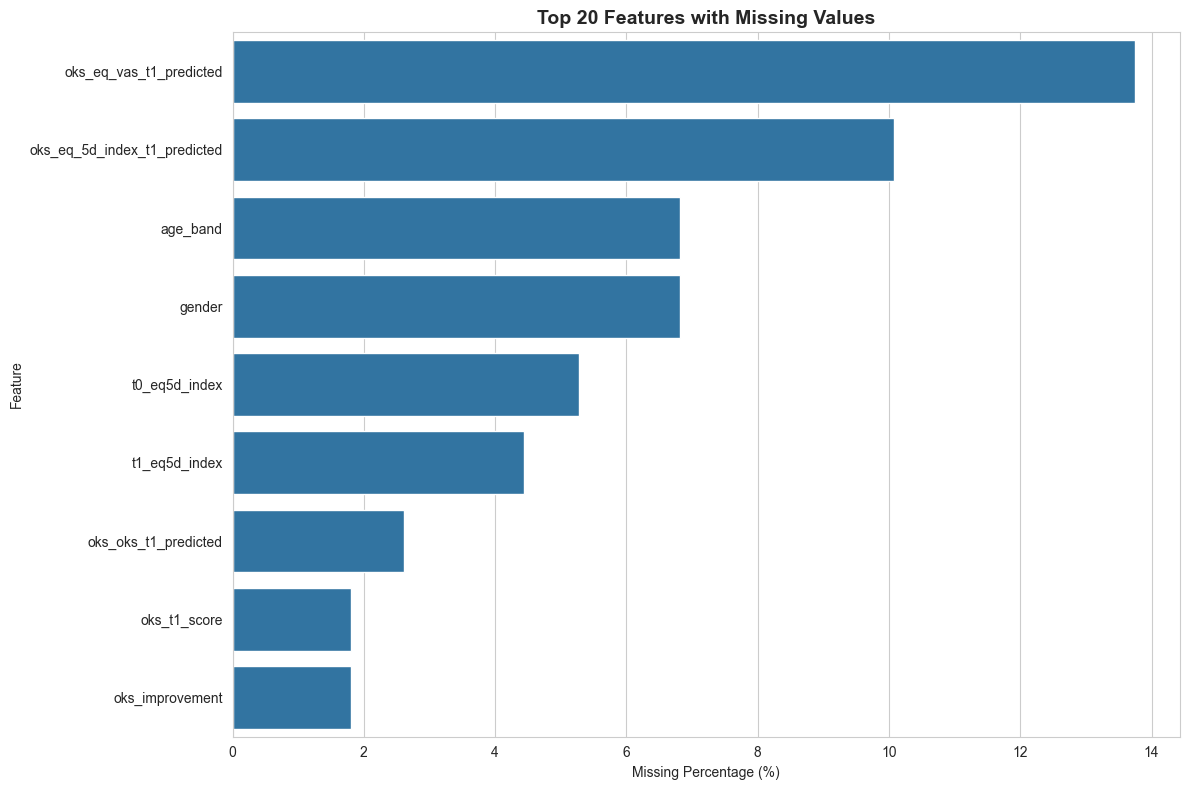

In [12]:
# Visualize missing values for top features
if len(missing_df_filtered) > 0:
    top_missing = missing_df_filtered.head(20)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=top_missing, y='column', x='missing_pct', ax=ax)
    ax.set_title('Top 20 Features with Missing Values', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

## 5. Exploratory Data Analysis of Safe Features

### 5.1 Baseline OKS Score Analysis

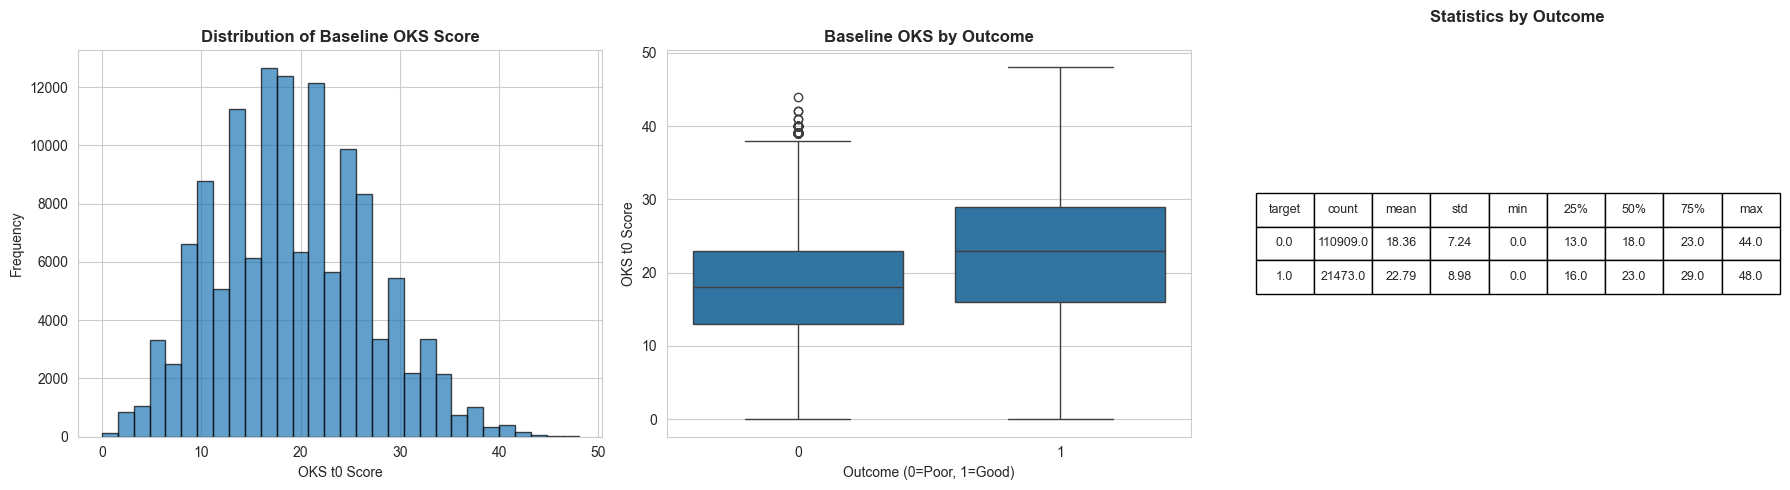


Mann-Whitney U test:
  Test statistic: 844601893.50
  P-value: 0.0000
  Significant at α=0.05: True


In [13]:
# Analyze baseline OKS score
if 'oks_t0_score' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Distribution
    axes[0].hist(df['oks_t0_score'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Baseline OKS Score', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('OKS t0 Score')
    axes[0].set_ylabel('Frequency')
    
    # By target
    df_plot = df.dropna(subset=['oks_t0_score', 'target'])
    sns.boxplot(data=df_plot, x='target', y='oks_t0_score', ax=axes[1])
    axes[1].set_title('Baseline OKS by Outcome', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Outcome (0=Poor, 1=Good)')
    axes[1].set_ylabel('OKS t0 Score')
    
    # Statistics by target
    stats_by_target = df_plot.groupby('target')['oks_t0_score'].describe()
    axes[2].axis('off')
    table_data = stats_by_target.round(2).reset_index()
    table = axes[2].table(cellText=table_data.values, colLabels=table_data.columns,
                          cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    axes[2].set_title('Statistics by Outcome', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical test
    poor_oks = df[df['target'] == 0]['oks_t0_score'].dropna()
    good_oks = df[df['target'] == 1]['oks_t0_score'].dropna()
    
    if len(poor_oks) > 0 and len(good_oks) > 0:
        statistic, pvalue = stats.mannwhitneyu(poor_oks, good_oks, alternative='two-sided')
        print(f"\nMann-Whitney U test:")
        print(f"  Test statistic: {statistic:.2f}")
        print(f"  P-value: {pvalue:.4f}")
        print(f"  Significant at α=0.05: {pvalue < 0.05}")

### 5.2 Demographic Features Analysis

In [14]:
# Analyze demographic features
demographic_cols = [col for col in df.columns if any(x in col.lower() for x in ['age', 'gender', 'sex'])]

print("Demographic Features:")
for col in demographic_cols:
    print(f"\n{col}:")
    if df[col].dtype in ['object', 'category']:
        print(df[col].value_counts())
        print(f"\nBy outcome:")
        print(pd.crosstab(df[col], df['target'], normalize='index') * 100)
    else:
        print(df[col].describe())
        print(f"\nBy outcome:")
        print(df.groupby('target')[col].describe())

Demographic Features:

age_band:
age_band
70 to 79     52211
60 to 69     43270
80 to 89     15007
50 to 59     12614
40 to 49       230
90 to 120       22
Name: count, dtype: int64

By outcome:
target             0          1
age_band                       
40 to 49   82.173913  17.826087
50 to 59   81.576027  18.423973
60 to 69   83.498960  16.501040
70 to 79   84.564555  15.435445
80 to 89   84.567202  15.432798
90 to 120  95.454545   4.545455

gender:
count    123354.000000
mean          1.572304
std           0.494747
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           2.000000
Name: gender, dtype: float64

By outcome:
           count      mean       std  min  25%  50%  75%  max
target                                                       
0       103473.0  1.577706  0.493927  1.0  1.0  2.0  2.0  2.0
1        19881.0  1.544188  0.498056  1.0  1.0  2.0  2.0  2.0


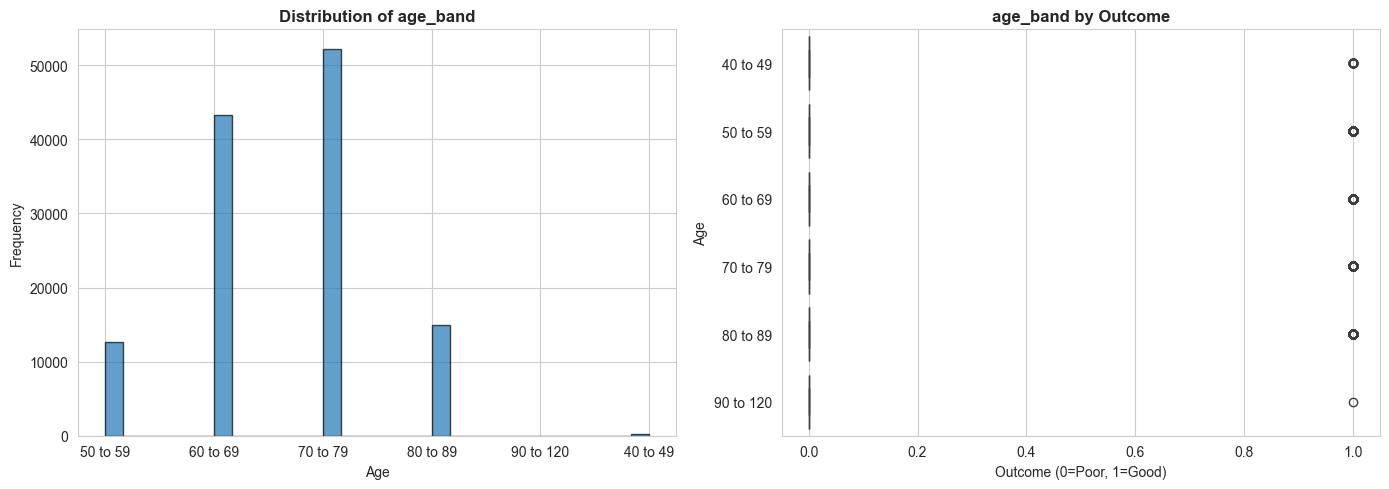

In [15]:
# Visualize age distribution if available
age_cols = [col for col in df.columns if 'age' in col.lower()]

if age_cols:
    age_col = age_cols[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall distribution
    axes[0].hist(df[age_col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Distribution of {age_col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    
    # By outcome
    df_plot = df.dropna(subset=[age_col, 'target'])
    sns.boxplot(data=df_plot, x='target', y=age_col, ax=axes[1])
    axes[1].set_title(f'{age_col} by Outcome', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Outcome (0=Poor, 1=Good)')
    axes[1].set_ylabel('Age')
    
    plt.tight_layout()
    plt.show()

### 5.3 Comorbidities and Health Conditions

In [16]:
# Identify comorbidity columns (only t0 - baseline)
comorbidity_cols = [col for col in df.columns if any(x in col.lower() for x in 
    ['comorbidity', 'diabetes', 'heart', 'cardiovascular', 'respiratory', 'bmi', 'weight', 'smoker', 'smoking'])]
comorbidity_cols = [col for col in comorbidity_cols if 't1' not in col.lower()]  # Exclude post-surgery

print(f"Comorbidity/Health Features Found: {len(comorbidity_cols)}")
for col in comorbidity_cols:
    print(f"  - {col}")

Comorbidity/Health Features Found: 2
  - heart_disease
  - diabetes


In [17]:
# Analyze each comorbidity feature
for col in comorbidity_cols[:5]:  # Show first 5
    print(f"\n{'='*80}")
    print(f"Feature: {col}")
    print(f"{'='*80}")
    
    if df[col].dtype in ['object', 'category', 'bool']:
        print("\nValue counts:")
        print(df[col].value_counts(dropna=False))
        
        print("\nOutcome rate by category:")
        ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
        print(ct)
    else:
        print("\nStatistics:")
        print(df[col].describe())
        
        print("\nBy outcome:")
        print(df.groupby('target')[col].describe())


Feature: heart_disease

Statistics:
count    132382.000000
mean          8.256757
std           2.322407
min           1.000000
25%           9.000000
50%           9.000000
75%           9.000000
max           9.000000
Name: heart_disease, dtype: float64

By outcome:
           count      mean       std  min  25%  50%  75%  max
target                                                       
0       110909.0  8.275803  2.295466  1.0  9.0  9.0  9.0  9.0
1        21473.0  8.158385  2.454564  1.0  9.0  9.0  9.0  9.0

Feature: diabetes

Statistics:
count    132382.000000
mean          8.007962
std           2.636706
min           1.000000
25%           9.000000
50%           9.000000
75%           9.000000
max           9.000000
Name: diabetes, dtype: float64

By outcome:
           count      mean       std  min  25%  50%  75%  max
target                                                       
0       110909.0  8.043035  2.596150  1.0  9.0  9.0  9.0  9.0
1        21473.0  7.826806  2.830113

## 6. Correlation Analysis (Safe Features Only)

In [18]:
# Select only safe numerical features for correlation
safe_numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove leakage features
safe_numerical_cols = [col for col in safe_numerical_cols if col not in leakage_features]

# Include target for correlation analysis
if 'target' not in safe_numerical_cols:
    safe_numerical_cols.append('target')

print(f"Safe numerical features for correlation: {len(safe_numerical_cols)}")
print(safe_numerical_cols[:20])  # Show first 20

Safe numerical features for correlation: 41
['gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_living_arrangements', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis', 't0_mobility']


In [19]:
# Calculate correlation with target
if len(safe_numerical_cols) > 1:
    correlations = df[safe_numerical_cols].corr()['target'].sort_values(ascending=False)
    correlations = correlations[correlations.index != 'target']  # Remove self-correlation
    
    print("Top 20 Features Correlated with Target:")
    print(correlations.head(20))
    
    print("\nBottom 20 Features Correlated with Target:")
    print(correlations.tail(20))

Top 20 Features Correlated with Target:
oks_t0_limping            0.219964
oks_t0_score              0.211726
oks_t0_pain               0.177756
oks_t0_work               0.168533
oks_t0_standing           0.162954
oks_t0_stairs             0.145955
oks_t0_walking            0.135542
oks_t0_transport          0.133462
oks_t0_shopping           0.131298
oks_t0_kneeling           0.130962
oks_t0_confidence         0.122158
oks_t0_night_pain         0.117792
t0_eq5d_index             0.096353
oks_t0_washing            0.080865
arthritis                 0.019458
t0_eq_vas                 0.015636
t0_anxiety                0.012194
t0_disability             0.010172
t0_living_arrangements    0.008387
t0_assisted               0.006995
Name: target, dtype: float64

Bottom 20 Features Correlated with Target:
high_bp                  0.003993
t0_self_care             0.002452
cancer                   0.001464
kidney_disease          -0.006643
nervous_system          -0.007670
t0_previous_surge

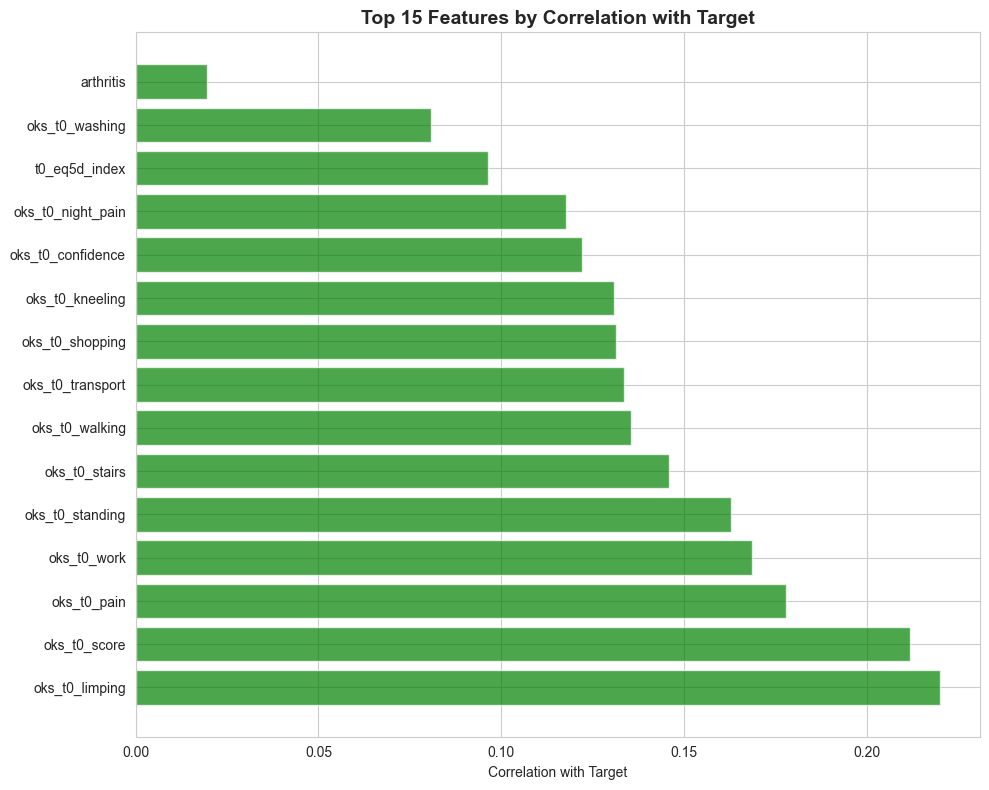

In [20]:
# Visualize top correlations
if len(safe_numerical_cols) > 1:
    top_corr = correlations.head(15)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['green' if x > 0 else 'red' for x in top_corr.values]
    ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_corr)))
    ax.set_yticklabels(top_corr.index)
    ax.set_xlabel('Correlation with Target')
    ax.set_title('Top 15 Features by Correlation with Target', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

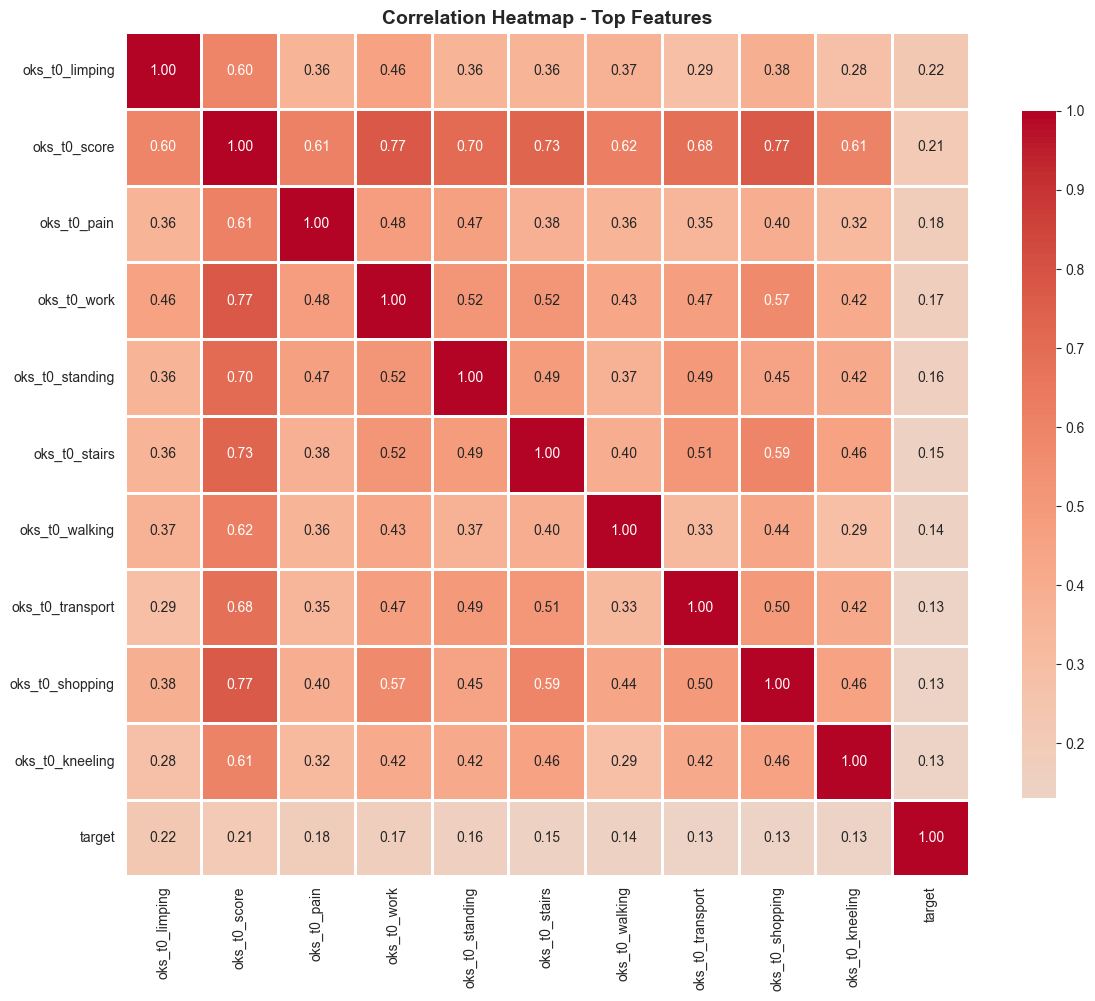

In [21]:
# Correlation heatmap for top features
if len(safe_numerical_cols) > 1:
    top_features = correlations.head(10).index.tolist() + ['target']
    
    if 'oks_t0_score' not in top_features:
        top_features.insert(0, 'oks_t0_score')
    
    corr_matrix = df[top_features].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Correlation Heatmap - Top Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7. Feature Engineering

Create new features based on domain knowledge while ensuring no data leakage.

In [22]:
# Create a copy for feature engineering
df_engineered = df.copy()

print("Starting feature engineering...")
print(f"Original features: {df.shape[1]}")

Starting feature engineering...
Original features: 83


### 7.1 Baseline OKS Categories

In [23]:
# Create OKS severity categories based on baseline
if 'oks_t0_score' in df_engineered.columns:
    # OKS scale: 0-48, higher is better
    # Categories based on knee function severity
    def categorize_oks(score):
        if pd.isna(score):
            return 'Unknown'
        elif score < 20:
            return 'Severe'  # Very poor function
        elif score < 30:
            return 'Moderate'  # Moderate impairment
        elif score < 40:
            return 'Mild'  # Mild impairment
        else:
            return 'Minimal'  # Good function
    
    df_engineered['oks_t0_category'] = df_engineered['oks_t0_score'].apply(categorize_oks)
    
    # Binary: severe baseline (potential ceiling effect for improvement)
    df_engineered['oks_t0_severe'] = (df_engineered['oks_t0_score'] < 20).astype(int)
    
    # Room for improvement (higher baseline = less room to improve)
    df_engineered['oks_room_for_improvement'] = 48 - df_engineered['oks_t0_score']
    
    print("✓ Created OKS baseline features")
    print("\nOKS t0 category distribution:")
    print(df_engineered['oks_t0_category'].value_counts())
    
    print("\nGood outcome rate by OKS category:")
    print(df_engineered.groupby('oks_t0_category')['target'].mean().sort_values(ascending=False))

✓ Created OKS baseline features

OKS t0 category distribution:
oks_t0_category
Severe      70791
Moderate    48670
Mild        12257
Minimal       664
Name: count, dtype: int64

Good outcome rate by OKS category:
oks_t0_category
Minimal     0.954819
Mild        0.373664
Moderate    0.171564
Severe      0.111723
Name: target, dtype: float64


### 7.2 Age-Related Features

In [24]:
# Age-based features
age_cols = [col for col in df_engineered.columns if 'age' in col.lower()]

if age_cols:
    age_col = age_cols[0]
    
    # Age groups
    def categorize_age(age):
        if pd.isna(age):
            return 'Unknown'
        elif age < 50:
            return '<50'
        elif age < 65:
            return '50-64'
        elif age < 75:
            return '65-74'
        else:
            return '75+'
    
    df_engineered['age_group'] = df_engineered[age_col].apply(categorize_age)
    
    # Elderly flag (higher risk for complications)
    df_engineered['is_elderly'] = (df_engineered[age_col] >= 75).astype(int)
    
    # Young patient (different expectations/outcomes)
    df_engineered['is_young'] = (df_engineered[age_col] < 50).astype(int)
    
    print("✓ Created age-related features")
    print("\nAge group distribution:")
    print(df_engineered['age_group'].value_counts())
    
    print("\nGood outcome rate by age group:")
    print(df_engineered.groupby('age_group')['target'].mean().sort_values(ascending=False))

TypeError: '<' not supported between instances of 'str' and 'int'

### 7.3 BMI Categories

In [ ]:
# BMI-related features
bmi_cols = [col for col in df_engineered.columns if 'bmi' in col.lower() and 't1' not in col.lower()]

if bmi_cols:
    bmi_col = bmi_cols[0]
    
    # WHO BMI categories
    def categorize_bmi(bmi):
        if pd.isna(bmi):
            return 'Unknown'
        elif bmi < 18.5:
            return 'Underweight'
        elif bmi < 25:
            return 'Normal'
        elif bmi < 30:
            return 'Overweight'
        elif bmi < 35:
            return 'Obese_Class1'
        elif bmi < 40:
            return 'Obese_Class2'
        else:
            return 'Obese_Class3'
    
    df_engineered['bmi_category'] = df_engineered[bmi_col].apply(categorize_bmi)
    
    # Obesity flags (known risk factor)
    df_engineered['is_obese'] = (df_engineered[bmi_col] >= 30).astype(int)
    df_engineered['is_severely_obese'] = (df_engineered[bmi_col] >= 35).astype(int)
    
    print("✓ Created BMI-related features")
    print("\nBMI category distribution:")
    print(df_engineered['bmi_category'].value_counts())
    
    print("\nGood outcome rate by BMI category:")
    print(df_engineered.groupby('bmi_category')['target'].mean().sort_values(ascending=False))

### 7.4 Comorbidity Count

In [ ]:
# Create comorbidity count (if comorbidity columns exist)
# Look for binary comorbidity indicators
potential_comorbidity_cols = [col for col in df_engineered.columns if 
    any(x in col.lower() for x in ['diabetes', 'heart', 'hypertension', 'copd', 'asthma', 
                                     'kidney', 'liver', 'cancer', 'depression', 'anxiety']) 
    and 't0' in col.lower()]

if potential_comorbidity_cols:
    print(f"Found {len(potential_comorbidity_cols)} potential comorbidity columns")
    
    # Count comorbidities
    comorbidity_count = df_engineered[potential_comorbidity_cols].sum(axis=1)
    df_engineered['comorbidity_count'] = comorbidity_count
    
    # High comorbidity burden
    df_engineered['high_comorbidity_burden'] = (comorbidity_count >= 3).astype(int)
    
    print("✓ Created comorbidity count features")
    print("\nComorbidity count distribution:")
    print(df_engineered['comorbidity_count'].value_counts().sort_index())
    
    print("\nGood outcome rate by comorbidity count:")
    print(df_engineered.groupby('comorbidity_count')['target'].mean())
else:
    print("No comorbidity columns found for counting")

### 7.5 Interaction Features

In [ ]:
# Create meaningful interactions

# Age x OKS interaction (older patients with worse baseline)
if 'oks_t0_score' in df_engineered.columns and age_cols:
    age_col = age_cols[0]
    df_engineered['age_x_oks_t0'] = df_engineered[age_col] * df_engineered['oks_t0_score']
    print("✓ Created age x OKS interaction")

# Age x BMI interaction
if bmi_cols and age_cols:
    df_engineered['age_x_bmi'] = df_engineered[age_cols[0]] * df_engineered[bmi_cols[0]]
    print("✓ Created age x BMI interaction")

# Elderly with high BMI (compound risk)
if 'is_elderly' in df_engineered.columns and 'is_obese' in df_engineered.columns:
    df_engineered['elderly_obese'] = df_engineered['is_elderly'] * df_engineered['is_obese']
    print("✓ Created elderly-obese compound risk feature")

# Poor baseline with high comorbidity
if 'oks_t0_severe' in df_engineered.columns and 'comorbidity_count' in df_engineered.columns:
    df_engineered['severe_with_comorbidity'] = df_engineered['oks_t0_severe'] * df_engineered['comorbidity_count']
    print("✓ Created severe OKS with comorbidity interaction")

### 7.6 Surgery-Related Features

In [ ]:
# Analyze surgery-related features
surgery_cols = [col for col in df_engineered.columns if any(x in col.lower() for x in 
    ['procedure', 'surgery', 'operation', 'revision', 'bilateral', 'unilateral', 'side'])]

print(f"Surgery-related columns: {len(surgery_cols)}")
for col in surgery_cols:
    print(f"  - {col}")
    if df_engineered[col].dtype in ['object', 'category']:
        print(f"    Values: {df_engineered[col].value_counts().to_dict()}")

### 7.7 Provider/Hospital Volume Features

In [ ]:
# Provider volume (if available)
provider_cols = [col for col in df_engineered.columns if any(x in col.lower() for x in 
    ['provider', 'hospital', 'surgeon', 'volume'])]

print(f"Provider-related columns: {len(provider_cols)}")
for col in provider_cols[:5]:  # Show first 5
    print(f"  - {col}")
    print(f"    Unique values: {df_engineered[col].nunique()}")

## 8. Summary of Engineered Features

In [ ]:
# Identify new features
original_cols = set(df.columns)
new_cols = [col for col in df_engineered.columns if col not in original_cols]

print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"\nOriginal features: {len(original_cols)}")
print(f"New features created: {len(new_cols)}")
print(f"Total features: {len(df_engineered.columns)}")

print("\nNew Features:")
for i, col in enumerate(new_cols, 1):
    print(f"  {i:2d}. {col}")
    print(f"      Type: {df_engineered[col].dtype}")
    print(f"      Missing: {df_engineered[col].isnull().sum()} ({df_engineered[col].isnull().mean()*100:.1f}%)")
    if df_engineered[col].dtype in ['object', 'category']:
        print(f"      Unique values: {df_engineered[col].nunique()}")
    else:
        print(f"      Range: [{df_engineered[col].min():.2f}, {df_engineered[col].max():.2f}]")

## 9. Feature Importance Analysis (Univariate)

In [ ]:
# Analyze correlation of new features with target
new_numerical = [col for col in new_cols if df_engineered[col].dtype in [np.number, 'int64', 'float64']]

if new_numerical:
    new_corr = df_engineered[new_numerical + ['target']].corr()['target'].sort_values(ascending=False)
    new_corr = new_corr[new_corr.index != 'target']
    
    print("Correlation of New Features with Target:")
    print(new_corr)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in new_corr.values]
    ax.barh(range(len(new_corr)), new_corr.values, color=colors, alpha=0.7)
    ax.set_yticks(range(len(new_corr)))
    ax.set_yticklabels(new_corr.index)
    ax.set_xlabel('Correlation with Target')
    ax.set_title('New Features Correlation with Target', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
# Analyze categorical new features
new_categorical = [col for col in new_cols if df_engineered[col].dtype in ['object', 'category']]

for col in new_categorical:
    print(f"\n{'='*80}")
    print(f"Feature: {col}")
    print(f"{'='*80}")
    
    # Distribution
    print("\nDistribution:")
    print(df_engineered[col].value_counts())
    
    # Outcome rate by category
    print("\nGood outcome rate by category:")
    outcome_rate = df_engineered.groupby(col)['target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    outcome_rate['mean'] = outcome_rate['mean'] * 100
    print(outcome_rate)
    
    # Chi-square test
    ct = pd.crosstab(df_engineered[col], df_engineered['target'])
    chi2, pval, dof, expected = stats.chi2_contingency(ct)
    print(f"\nChi-square test: χ²={chi2:.2f}, p-value={pval:.4f}")

## 10. Final Feature Set Preparation

In [ ]:
# Prepare final feature set (remove leakage features)
features_to_exclude = leakage_features + ['oks_improvement']  # Exclude all leakage features
features_to_exclude = [col for col in features_to_exclude if col in df_engineered.columns]

# Create final dataset
df_final = df_engineered.drop(columns=features_to_exclude)

print("="*80)
print("FINAL FEATURE SET")
print("="*80)
print(f"\nTotal features: {df_final.shape[1]}")
print(f"Total samples: {df_final.shape[0]:,}")
print(f"\nTarget distribution:")
print(df_final['target'].value_counts())
print(f"\nExcluded features (data leakage): {len(features_to_exclude)}")
for col in features_to_exclude:
    print(f"  - {col}")

In [ ]:
# Save engineered dataset
output_path = '../data/cleaned/knee-provider-featured.parquet'
df_final.to_parquet(output_path, index=False)
print(f"\n✓ Saved engineered dataset to: {output_path}")

## 11. Key Findings and Recommendations

In [ ]:
print("""
=====================================================================
KEY FINDINGS AND RECOMMENDATIONS FOR MODELING
=====================================================================

1. DATA LEAKAGE PREVENTION:
   ✓ Excluded all t1 (post-surgery) features
   ✓ Only using baseline (t0) and pre-surgery information
   ✓ Target variable uses t1 data ONLY for labeling

2. ENGINEERED FEATURES:
   - Baseline OKS categories (severity levels)
   - Room for improvement (ceiling effects)
   - Age groups and risk categories
   - BMI categories and obesity flags
   - Comorbidity burden counts
   - Interaction features (age x OKS, elderly + obese, etc.)

3. IMPORTANT PREDICTORS (based on correlation/analysis):
   - Baseline OKS score (oks_t0_score)
   - Age-related features
   - BMI and obesity status
   - Comorbidity burden
   - Surgery type/details

4. RECOMMENDATIONS FOR MODELING:
   a) Handle missing values appropriately:
      - Use imputation for critical features
      - Consider missing indicators for informative missingness
   
   b) Feature scaling:
      - Standardize numerical features
      - One-hot encode categorical features
   
   c) Class imbalance:
      - Check target distribution
      - Consider SMOTE, class weights, or stratified sampling
   
   d) Feature selection:
      - Use tree-based importance or LASSO
      - Consider domain knowledge
      - Remove highly correlated features
   
   e) Model selection:
      - Try multiple algorithms (LogReg, RF, XGBoost, LightGBM)
      - Use cross-validation
      - Focus on metrics relevant to healthcare (precision, recall, AUC)
   
   f) Validation strategy:
      - Use stratified k-fold CV
      - Consider temporal validation if date available
      - Hold out test set for final evaluation

5. NEXT STEPS:
   - Perform train-test split
   - Build preprocessing pipeline
   - Train baseline models
   - Tune hyperparameters
   - Evaluate and interpret results
""")

## 12. Data Quality Check Summary

In [ ]:
# Final data quality summary
print("="*80)
print("DATA QUALITY SUMMARY")
print("="*80)

# Missing values
missing_summary = df_final.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print(f"\nFeatures with missing values: {len(missing_summary)}")
if len(missing_summary) > 0:
    print("\nTop 10 features by missing count:")
    print(missing_summary.head(10))

# Duplicates
duplicates = df_final.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Target distribution
print("\nTarget distribution:")
target_dist = df_final['target'].value_counts()
print(target_dist)
print(f"\nClass balance ratio: {target_dist.min() / target_dist.max():.2f}")

# Data types
print("\nData types distribution:")
print(df_final.dtypes.value_counts())

print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE")
print("="*80)

In [ ]:
# Analyze variables for potential 9-based missing value indicators
# We'll check for patterns like 9, 99, 999, 9999 that might indicate missing values

def analyze_nine_patterns(df):
    """
    Analyze each column to detect if it uses 9-based patterns as missing indicators.
    Returns a DataFrame with columns that have suspicious 9-based patterns.
    """
    results = []
    
    for col in df.columns:
        col_data = df[col]
        
        # Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(col_data):
            continue
        
        # Get value counts
        value_counts = col_data.value_counts().sort_index()
        
        # Check for common missing value patterns
        patterns = {
            'has_9': 9 in value_counts.index,
            'has_99': 99 in value_counts.index,
            'has_999': 999 in value_counts.index,
            'has_9999': 9999 in value_counts.index,
            'count_9': value_counts.get(9, 0),
            'count_99': value_counts.get(99, 0),
            'count_999': value_counts.get(999, 0),
            'count_9999': value_counts.get(9999, 0),
        }
        
        # Calculate percentages
        total = len(col_data)
        patterns['pct_9'] = (patterns['count_9'] / total * 100) if patterns['count_9'] > 0 else 0
        patterns['pct_99'] = (patterns['count_99'] / total * 100) if patterns['count_99'] > 0 else 0
        patterns['pct_999'] = (patterns['count_999'] / total * 100) if patterns['count_999'] > 0 else 0
        patterns['pct_9999'] = (patterns['count_9999'] / total * 100) if patterns['count_9999'] > 0 else 0
        
        # Check if any 9-pattern exists
        has_any_pattern = any([patterns['has_9'], patterns['has_99'], 
                               patterns['has_999'], patterns['has_9999']])
        
        if has_any_pattern:
            # Get basic stats
            patterns['column'] = col
            patterns['dtype'] = str(col_data.dtype)
            patterns['unique_values'] = col_data.nunique()
            patterns['min'] = col_data.min()
            patterns['max'] = col_data.max()
            patterns['mean'] = col_data.mean()
            patterns['median'] = col_data.median()
            patterns['total_count'] = total
            patterns['actual_missing'] = col_data.isnull().sum()
            
            results.append(patterns)
    
    return pd.DataFrame(results)

print("Analyzing dataset for 9-based missing value indicators...")
print("="*80)

# Load the data
nine_patterns_df = analyze_nine_patterns(df)

if len(nine_patterns_df) > 0:
    # Sort by most frequent 9-pattern first
    nine_patterns_df['max_nine_count'] = nine_patterns_df[['count_9', 'count_99', 'count_999', 'count_9999']].max(axis=1)
    nine_patterns_df['max_nine_pct'] = nine_patterns_df[['pct_9', 'pct_99', 'pct_999', 'pct_9999']].max(axis=1)
    nine_patterns_df = nine_patterns_df.sort_values('max_nine_pct', ascending=False)
    
    print(f"\nFound {len(nine_patterns_df)} variables with 9-based patterns")
    print("\n" + "="*80)
else:
    print("\nNo 9-based patterns found in the dataset")

nine_patterns_df.head(20)

Analyzing dataset for 9-based missing value indicators...

Found 44 variables with 9-based patterns



,has_9,has_99,has_999,has_9999,count_9,count_99,count_999,count_9999,pct_9,pct_99,...,dtype,unique_values,min,max,mean,median,total_count,actual_missing,max_nine_count,max_nine_pct
13,True,False,False,False,129232,0,0,0,99.422232,0.000000,...,uint8,2,1.0,9.0,8.953779,9.0,129983,0,129232,99.422232
12,True,False,False,False,128694,0,0,0,99.008332,0.000000,...,uint8,2,1.0,9.0,8.920667,9.0,129983,0,128694,99.008332
7,True,False,False,False,127852,0,0,0,98.360555,0.000000,...,uint8,2,1.0,9.0,8.868844,9.0,129983,0,127852,98.360555
11,True,False,False,False,127361,0,0,0,97.982813,0.000000,...,uint8,2,1.0,9.0,8.838625,9.0,129983,0,127361,97.982813
14,True,False,False,False,122947,0,0,0,94.586984,0.000000,...,uint8,2,1.0,9.0,8.566959,9.0,129983,0,122947,94.586984
8,True,False,False,False,122817,0,0,0,94.486971,0.000000,...,uint8,2,1.0,9.0,8.558958,9.0,129983,0,122817,94.486971
23,True,False,False,False,119945,0,0,0,92.277452,0.000000,...,uint8,7,1.0,9.0,8.416062,9.0,129983,0,119945,92.277452
9,True,False,False,False,118139,0,0,0,90.888039,0.000000,...,uint8,2,1.0,9.0,8.271043,9.0,129983,0,118139,90.888039
15,True,False,False,False,117988,0,0,0,90.771870,0.000000,...,uint8,2,1.0,9.0,8.261750,9.0,129983,0,117988,90.771870
5,True,False,False,False,117940,0,0,0,90.734942,0.000000,...,uint8,2,1.0,9.0,8.258795,9.0,129983,0,117940,90.734942


In [ ]:
# Display detailed information about columns with 9-patterns
if len(nine_patterns_df) > 0:
    # Select key columns for display
    display_cols = ['column', 'has_9', 'count_9', 'pct_9', 
                    'has_99', 'count_99', 'pct_99',
                    'unique_values', 'min', 'max', 'median', 'actual_missing']
    
    print("\n" + "="*80)
    print("DETAILED ANALYSIS OF VARIABLES WITH 9-BASED PATTERNS")
    print("="*80)
    
    display_df = nine_patterns_df[display_cols].copy()
    display_df = display_df.round(2)
    
    # Format for better readability
    print("\nColumns with value = 9:")
    df_with_9 = display_df[display_df['has_9'] == True].sort_values('pct_9', ascending=False)
    if len(df_with_9) > 0:
        print(df_with_9[['column', 'count_9', 'pct_9', 'unique_values', 'min', 'max', 'median', 'actual_missing']].to_string())
    else:
        print("None found")
    
    print("\n" + "-"*80)
    print("Columns with value = 99:")
    df_with_99 = display_df[display_df['has_99'] == True].sort_values('pct_99', ascending=False)
    if len(df_with_99) > 0:
        print(df_with_99[['column', 'count_99', 'pct_99', 'unique_values', 'min', 'max', 'median', 'actual_missing']].to_string())
    else:
        print("None found")


DETAILED ANALYSIS OF VARIABLES WITH 9-BASED PATTERNS

Columns with value = 9:
                    column  count_9  pct_9  unique_values   min    max  median  actual_missing
13           liver_disease   129232  99.42              2   1.0    9.0     9.0               0
12          nervous_system   128694  99.01              2   1.0    9.0     9.0               0
7                   stroke   127852  98.36              2   1.0    9.0     9.0               0
11          kidney_disease   127361  97.98              2   1.0    9.0     9.0               0
14                  cancer   122947  94.59              2   1.0    9.0     9.0               0
8              circulation   122817  94.49              2   1.0    9.0     9.0               0
23          t1_assisted_by   119945  92.28              7   1.0    9.0     9.0               0
9             lung_disease   118139  90.89              2   1.0    9.0     9.0               0
15              depression   117988  90.77              2   1.0   